# HAM10000 — Clasificador Baseline (EfficientNet-B0)

Benchmark inicial usando EfficientNet-B0 preentrenado en ImageNet.
Este notebook establece el punto de referencia para comparar los escenarios con datos sintéticos.

**Pipeline**:
1. Cargar config y splits (producidos por `02_split.py`)
2. Inicializar dataset y dataloaders
3. Construir modelo y revisar device
4. Entrenar con CrossEntropyLoss ponderada + WeightedRandomSampler
5. Evaluar en test: recall, F1, AUC (melanoma)
6. Guardar experimento en `experiments/`

## 0. Setup

In [2]:
import sys
import json
import uuid
from datetime import datetime, timezone
from pathlib import Path

import yaml
import torch

# Añadir raíz al path para importar módulos del proyecto
ROOT = Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.training.dataset import make_loaders
from scripts.training.model import build_model, get_device
from scripts.training.train import train
from scripts.training.evaluate import evaluate

cfg = yaml.safe_load((ROOT / 'config/project.yaml').read_text())
print('Config cargado:', cfg['project']['name'])

Config cargado: HAM10000 Synthetic Augmentation Research


## 1. Registrar experimento

In [3]:
SCENARIO   = 'real_only'   # benchmark: sin datos sintéticos
EPOCHS     = 15
BATCH_SIZE = 32
LR         = 1e-4
SEED       = cfg['project']['seed']

torch.manual_seed(SEED)

run_id  = f"{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}_{SCENARIO}"
run_dir = ROOT / cfg['paths']['experiments'] / run_id
run_dir.mkdir(parents=True, exist_ok=True)

run_config = {
    'run_id':    run_id,
    'scenario':  SCENARIO,
    'model':     'efficientnet_b0',
    'pretrained': True,
    'epochs':    EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr':        LR,
    'seed':      SEED,
    'dataset':   cfg['dataset'],
    'started_at': datetime.now(timezone.utc).isoformat(),
}
(run_dir / 'config.json').write_text(json.dumps(run_config, indent=2))
print(f'Run: {run_id}')
print(f'Guardando en: {run_dir.relative_to(ROOT)}')

Run: 20260426_204545_real_only
Guardando en: experiments/20260426_204545_real_only


## 2. Dataset y distribución de clases

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

SPLITS_DIR = ROOT / cfg['paths']['data_processed'] / 'splits'

# Mostrar distribución de clases
for split in ('train', 'val', 'test'):
    df = pd.read_csv(SPLITS_DIR / f'{split}.csv')
    counts = df['dx'].value_counts()
    total  = len(df)
    print(f"{split:5s}: {total:5d} imgs | "
          f"nv={counts.get('nv',0)} ({counts.get('nv',0)/total:.1%}) | "
          f"mel={counts.get('mel',0)} ({counts.get('mel',0)/total:.1%})")

train:  5476 imgs | nv=4675 (85.4%) | mel=801 (14.6%)
val  :  1171 imgs | nv=1018 (86.9%) | mel=153 (13.1%)
test :  1171 imgs | nv=1012 (86.4%) | mel=159 (13.6%)


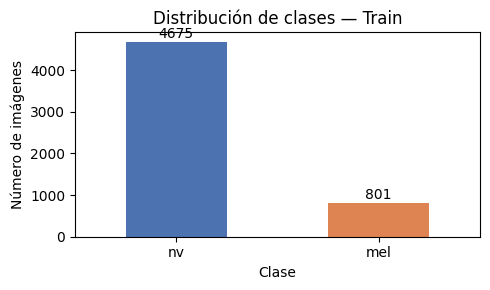

In [5]:
# Visualizar balance de clases en train
train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
fig, ax = plt.subplots(figsize=(5, 3))
train_df['dx'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Distribución de clases — Train')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de imágenes')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height())}', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(ROOT / cfg['paths']['reports'] / 'class_distribution.png', dpi=150)
plt.show()

## 3. DataLoaders

In [6]:
NUM_WORKERS = 0  # 0 en WSL/CPU para evitar OOM por forking de workers

device = get_device()

train_loader, val_loader, test_loader = make_loaders(
    SPLITS_DIR, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, device=device
)

imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  |  Labels: {labels.unique(return_counts=True)}')

/home/schica/anaconda3/envs/ham10000-augmentation/lib/python3.11/site-packages/torch/cuda/__init__.py:371: UserWarning: Found GPU0 NVIDIA GeForce GTX 1050 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/schica/anaconda3/envs/ham10000-augmentation/lib/python3.11/site-packages/torch/cuda/__init__.py:489: UserWarning: 
NVIDIA GeForce GTX 1050 with CUDA capability sm_61 is not compatibl

GPU detectada (NVIDIA GeForce GTX 1050, sm_61) no es compatible con esta build de PyTorch.
  PyTorch soporta: sm_75, sm_80, sm_86, sm_90, sm_100, sm_120
  Cayendo a CPU para evitar errores de kernel.
Batch shape: torch.Size([32, 3, 224, 224])  |  Labels: (tensor([0, 1]), tensor([10, 22]))


## 4. Modelo y device

In [7]:
model = build_model(num_classes=2, pretrained=True)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device en uso: {device}')
print(f'Parámetros totales:    {total_params:,}')
print(f'Parámetros entrenables: {trainable:,}')

Device en uso: cpu
Parámetros totales:    4,010,110
Parámetros entrenables: 4,010,110


## 5. Entrenamiento

In [8]:
from scripts.training.dataset import HAM10000Dataset
from scripts.training.dataset import TRAIN_TRANSFORMS
import torch

# Pesos de clase para la loss (inverso de frecuencia)
train_ds = HAM10000Dataset(SPLITS_DIR / 'train.csv', transform=TRAIN_TRANSFORMS)
counts   = train_ds.df['label'].value_counts().sort_index().values
class_weights = torch.tensor(counts.max() / counts, dtype=torch.float)
print(f'Class weights: nv={class_weights[0]:.3f}, mel={class_weights[1]:.3f}')

Class weights: nv=1.000, mel=5.836


In [9]:
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    run_dir=run_dir,
    epochs=EPOCHS,
    lr=LR,
    class_weights=class_weights,
)

Epoch 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

Epoch 01/15 | loss=0.6411 acc=0.765 | val_loss=1.6360 val_f1_mel=0.445 val_auc=0.868 | 739s


Epoch 02/15:   0%|          | 0/172 [00:00<?, ?it/s]

Epoch 02/15 | loss=0.3592 acc=0.812 | val_loss=1.3635 val_f1_mel=0.477 val_auc=0.910 | 688s


Epoch 03/15:   0%|          | 0/172 [00:00<?, ?it/s]

...

Epoch 13/15 | loss=0.0666 acc=0.947 | val_loss=0.4467 val_f1_mel=0.585 val_auc=0.922 | 956s


Epoch 14/15:   0%|          | 0/172 [00:00<?, ?it/s]

Epoch 14/15 | loss=0.0586 acc=0.950 | val_loss=0.4644 val_f1_mel=0.575 val_auc=0.925 | 1017s


Epoch 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

Epoch 15/15 | loss=0.0717 acc=0.943 | val_loss=0.4724 val_f1_mel=0.581 val_auc=0.926 | 986s


## 6. Curvas de entrenamiento

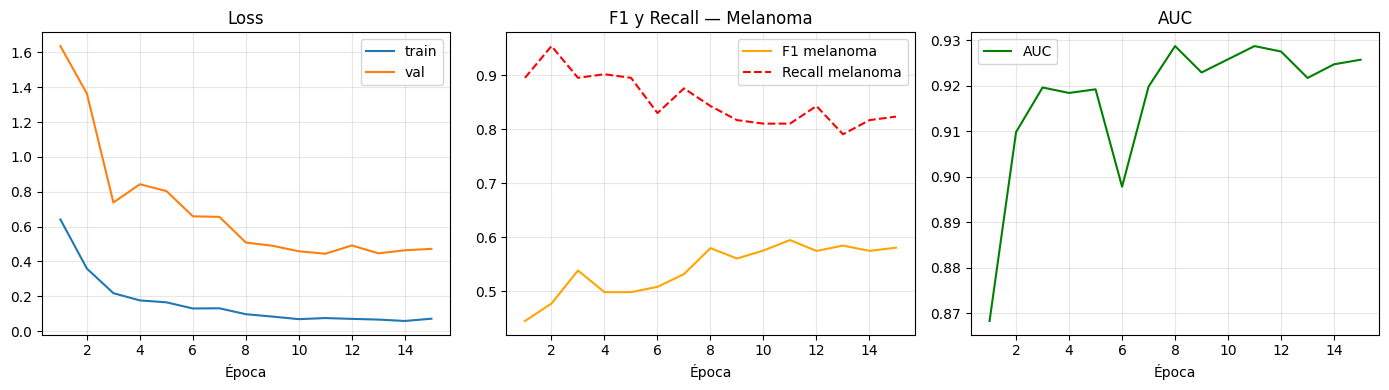

In [10]:
import pandas as pd

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_f1_mel'], label='F1 melanoma', color='orange')
axes[1].plot(hist_df['epoch'], hist_df['val_recall_mel'], label='Recall melanoma', color='red', linestyle='--')
axes[1].set_title('F1 y Recall — Melanoma')
axes[1].legend()

axes[2].plot(hist_df['epoch'], hist_df['val_auc'], label='AUC', color='green')
axes[2].set_title('AUC')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Época')
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(run_dir / 'training_curves.png', dpi=150)
plt.show()

## 7. Evaluación final en test

In [11]:
test_metrics = evaluate(
    model=model,
    test_loader=test_loader,
    device=device,
    run_dir=run_dir,
)

print('\n=== BENCHMARK BASELINE (real_only) ===')
for k, v in test_metrics.items():
    print(f'  {k:20s}: {v:.4f}')


=== BENCHMARK BASELINE (real_only) ===
  auc                 : 0.9259
  f1_mel              : 0.6036
  recall_mel          : 0.8428
  precision_mel       : 0.4702
  f1_nv               : 0.9073
  accuracy            : 0.8497


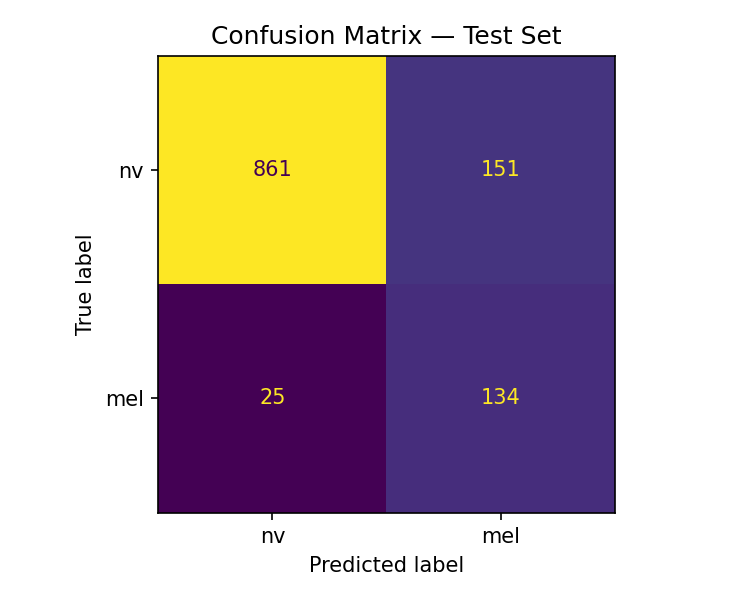

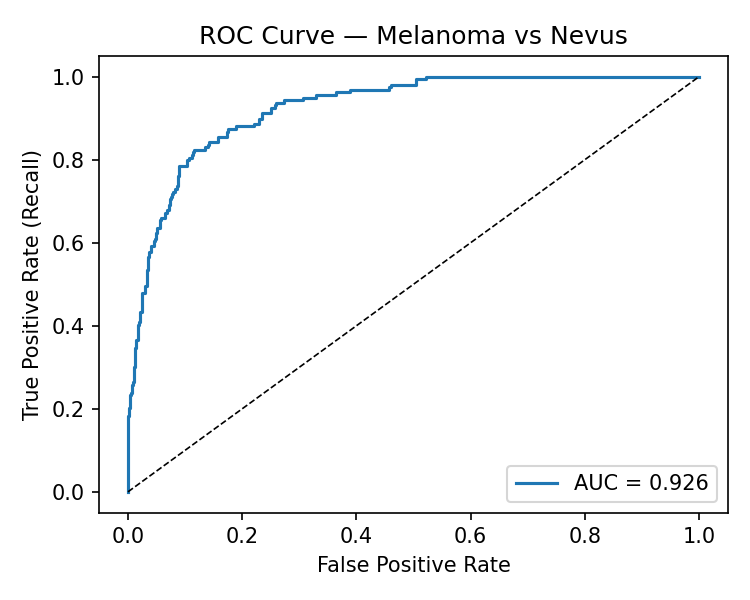

In [12]:
# Mostrar matriz de confusión y ROC ya guardadas
from IPython.display import Image, display
display(Image(str(run_dir / 'confusion_matrix.png')))
display(Image(str(run_dir / 'roc_curve.png')))

## 8. Cerrar experimento

In [13]:
run_config['finished_at'] = datetime.now(timezone.utc).isoformat()
run_config['test_metrics'] = test_metrics
(run_dir / 'config.json').write_text(json.dumps(run_config, indent=2))

print(f'Experimento guardado en: experiments/{run_id}/')
print('Archivos:')
for f in sorted(run_dir.iterdir()):
    print(f'  {f.name}')

Experimento guardado en: experiments/20260426_204545_real_only/
Archivos:
  best_model.pt
  classification_report.json
  config.json
  confusion_matrix.png
  history.json
  roc_curve.png
  test_metrics.json
  training_curves.png
